# Basic ChatBot Using Langgraph


In [43]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage,HumanMessage
from langchain_huggingface import ChatHuggingFace,HuggingFaceEndpoint
from langgraph.graph.message import add_messages
load_dotenv()
from langgraph.checkpoint.memory import MemorySaver

In [44]:
class ChatState(TypedDict):
    messages:Annotated[list[BaseMessage],add_messages]

In [45]:
llm=HuggingFaceEndpoint(
    repo_id="openai/gpt-oss-120b",
    task="text-generation"
)

model=ChatHuggingFace(llm=llm)

In [46]:
def chat_node(state:ChatState)->ChatState:
    messages=state['messages']

    response=model.invoke(messages)

    return{
        'messages':[response]
    }

In [47]:
checkpointer=MemorySaver()
graph=StateGraph(ChatState)

graph.add_node("Chat Node",chat_node)

graph.add_edge(START,"Chat Node")
graph.add_edge("Chat Node",END)

chatbot=graph.compile(checkpointer=checkpointer)

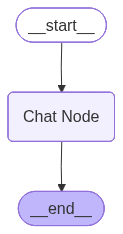

In [48]:
chatbot

In [49]:
initial_state = {
    'messages': [HumanMessage(content='What is the capital of india')]
}
config={
    'configurable':{
        'thread_id':'1'
    }
}

chatbot.invoke(initial_state,config=config)['messages'][-1].content
# chatbot.invoke(initial_state)['messages'][-1].content

'The capital of India is **New\u202fDelhi**. It serves as the seat of the Indian government, housing the President’s residence (Rashtrapati Bhavan), Parliament, and many ministries.'

In [50]:
thread_id='1'

while True:
    user_messages=input('Type here: ')
    print("User:",user_messages)
    if user_messages.strip().lower() in ['exit','quit','bye']:
        break

    config={'configurable':{'thread_id':thread_id}}
    response=chatbot.invoke({'messages':[HumanMessage(content=user_messages)]},config=config)

    print("AI:",response['messages'][-1].content)

User: my name is amrit
AI: Nice to meet you, Amrit! How can I assist you today?
User: what is my name?
AI: You told me your name is **Amrit**. 🌟
User: ok 
AI: Got it! 😊 What would you like to talk about or need help with today, Amrit?
User: bye


In [51]:
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='What is the capital of india', additional_kwargs={}, response_metadata={}, id='7e7478ca-cd0f-49fe-b6f6-6e998ddd2523'), AIMessage(content='The capital of India is **New\u202fDelhi**. It serves as the seat of the Indian government, housing the President’s residence (Rashtrapati Bhavan), Parliament, and many ministries.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 78, 'prompt_tokens': 73, 'total_tokens': 151}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_46358675aa6b1ba4d98d', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e54c6-aa32-7822-81c1-d12fabec5f61-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 78, 'total_tokens': 151}), HumanMessage(content='my name is amrit', additional_kwargs={}, response_metadata={}, id='fcb8248c-93a2-4583-be50-b79d7b54d237'), AIMessage(content='Nice to meet you, Amrit! How can I assist you to